<a href="https://colab.research.google.com/github/davianella/Fly/blob/main/Fuzzy%20Prob.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ===============================
# KEANGGOTAAN KECEPATAN ANGIN
# ===============================
def mu_kecepatan(kmh):
    if kmh <= 0:
        rendah = 1.0
    elif 0 < kmh < 4:
        rendah = (4 - kmh) / 4
    else:
        rendah = 0.0

    if 0 < kmh < 9:
        cukup = kmh / 9
    elif 9 <= kmh < 18:
        cukup = (18 - kmh) / (18 - 9)
    else:
        cukup = 0.0

    if kmh <= 15:
        tinggi = 0.0
    elif 15 < kmh < 20:
        tinggi = (kmh - 15) / (20 - 15)
    else:
        tinggi = 1.0

    return {
        "rendah": float(np.clip(rendah, 0, 1)),
        "cukup": float(np.clip(cukup, 0, 1)),
        "tinggi": float(np.clip(tinggi, 0, 1))
    }

def mu_gust(g):
    # === STABIL (linier TURUN) ===
    if g <= 10:
        stabil = 1.0
    elif 10 < g < 20:
        stabil = (20 - g) / (20 - 10)
    else:
        stabil = 0.0

    # === BERBAHAYA (linier NAIK) ===
    if g <= 15:
        berbahaya = 0.0
    elif 15 < g < 30:
        berbahaya = (g - 15) / (30 - 15)
    else:
        berbahaya = 1.0

    return {
        "stabil": float(np.clip(stabil, 0, 1)),
        "berbahaya": float(np.clip(berbahaya, 0, 1))
    }



# ===============================
# KEANGGOTAAN ARAH ANGIN
# ===============================

def mu_arah(deg):
    deg = deg % 360

    # ---------- HEADWIND ----------
    if 90 <= deg <= 180:
        if deg < 110:
            headwind = (deg - 90) / (110 - 90)  # Naik dari 90 ke 110
        elif 110 <= deg <= 155:
            headwind = 1.0                     # PLATU/DATAR (Puncak 10 derajat kanan-kiri)
        else:
            headwind = (180 - deg) / (180 - 155) # Turun dari 145 ke 180
    else:
        headwind = 0.0

    # ---------- CROSSWIND ----------
    if 45 <= deg <= 135:
        if deg <= 90:
            crosswind = (deg - 45) / 45
        else:
            crosswind = (135 - deg) / 45

    elif 135 < deg <= 225:
        if deg <= 180:
            crosswind = (deg - 135) / 45
        else:
            crosswind = (225 - deg) / 45

    else:
        crosswind = 0.0

    # ---------- TAILWIND ----------
    if deg < 45:
        tailwind = 1.0

    elif 45 <= deg < 90:
        # turun linier dari 1 → 0
        tailwind = (90 - deg) / 45

    elif 90 <= deg <= 180:
        tailwind = 0.0

    elif 180 < deg <= 225:
        # naik linier dari 0 → 1
        tailwind = (deg - 180) / 45

    else:  # deg > 225
        tailwind = 1.0


    return {
        "headwind": float(np.clip(headwind, 0, 1)),
        "crosswind": float(np.clip(crosswind, 0, 1)),
        "tailwind": float(np.clip(tailwind, 0, 1))
    }

# ===============================
# KEANGGOTAAN KODE CUACA
# ===============================
def mu_weather_code(code):
    # Pastikan code numerik
    try:
        code = int(code)
    except:
        return {
            'cerah': 0.0,
            'berawan': 0.0,
            'berkabut': 0.0,
            'not_flyable': 0.0
        }

    # Clear / partly cloudy / overcast
    if code == [0, 1]:
        return {
            'cerah': 1.0,
            'berawan': 0.0,
            'berkabut': 0.0,
            'not_flyable': 0.0
        }

    if code in [2, 3]:
        return {
            'cerah': 0.0,
            'berawan': 1.0,
            'berkabut': 0.0,
            'not_flyable': 0.0
        }

    # Fog (45, 48)
    if code in [45, 48]:
        return {
            'cerah': 0.0,
            'berawan': 0.0,
            'berkabut': 1.0,
            'not_flyable': 0.0
        }

    # === NOT FLYABLE (MUTLAK) ===
    if code in [
        51, 53, 55,       # drizzle
        56, 57,           # freezing drizzle
        61, 63, 65,       # rain
        66, 67,           # freezing rain
        71, 73, 75,       # snow fall
        77,               # snow grains
        80, 81, 82,       # rain showers
        85, 86,           # snow showers
        95, 96, 99        # thunderstorm + hail
    ]:
        return {
            'cerah': 0.0,
            'berawan': 0.0,
            'berkabut': 0.0,
            'not_flyable': 1.0
        }

    # Default aman (jika code tidak dikenal)
    return {
        'cerah': 0.0,
        'berawan': 0.0,
        'berkabut': 0.0,
        'not_flyable': 0.0
    }


# ===============================
# VISIBILITAS DEPAN
# ===============================
def mu_vis_depan(m):
    rendah = 1.0 if m <= 2000 else (3000 - m) / 1000 if 2000 < m < 3000 else 0.0
    sedang = (m - 2500) / 2500 if 2500 < m < 5000 else (6000 - m) / 1000 if 5000 <= m < 6000 else 0.0
    tinggi = 0.0 if m <= 5000 else (m - 5000) / 1000 if 5000 < m < 6000 else 1.0

    return {
        "rendah": float(np.clip(rendah, 0, 1)),
        "sedang": float(np.clip(sedang, 0, 1)),
        "tinggi": float(np.clip(tinggi, 0, 1))
    }

# ===============================
# VISIBILITAS ATAS
# ===============================
def mu_vis_atas(m):
    rendah = 1.0 if m <= 200 else (300 - m) / 100 if 200 < m < 300 else 0.0
    sedang = (m - 250) / 250 if 250 < m < 500 else (600 - m) / 100 if 500 <= m < 600 else 0.0
    tinggi = 0.0 if m <= 500 else (m - 500) / 100 if 500 < m < 600 else 1.0

    return {
        "rendah": float(np.clip(rendah, 0, 1)),
        "sedang": float(np.clip(sedang, 0, 1)),
        "tinggi": float(np.clip(tinggi, 0, 1))
    }


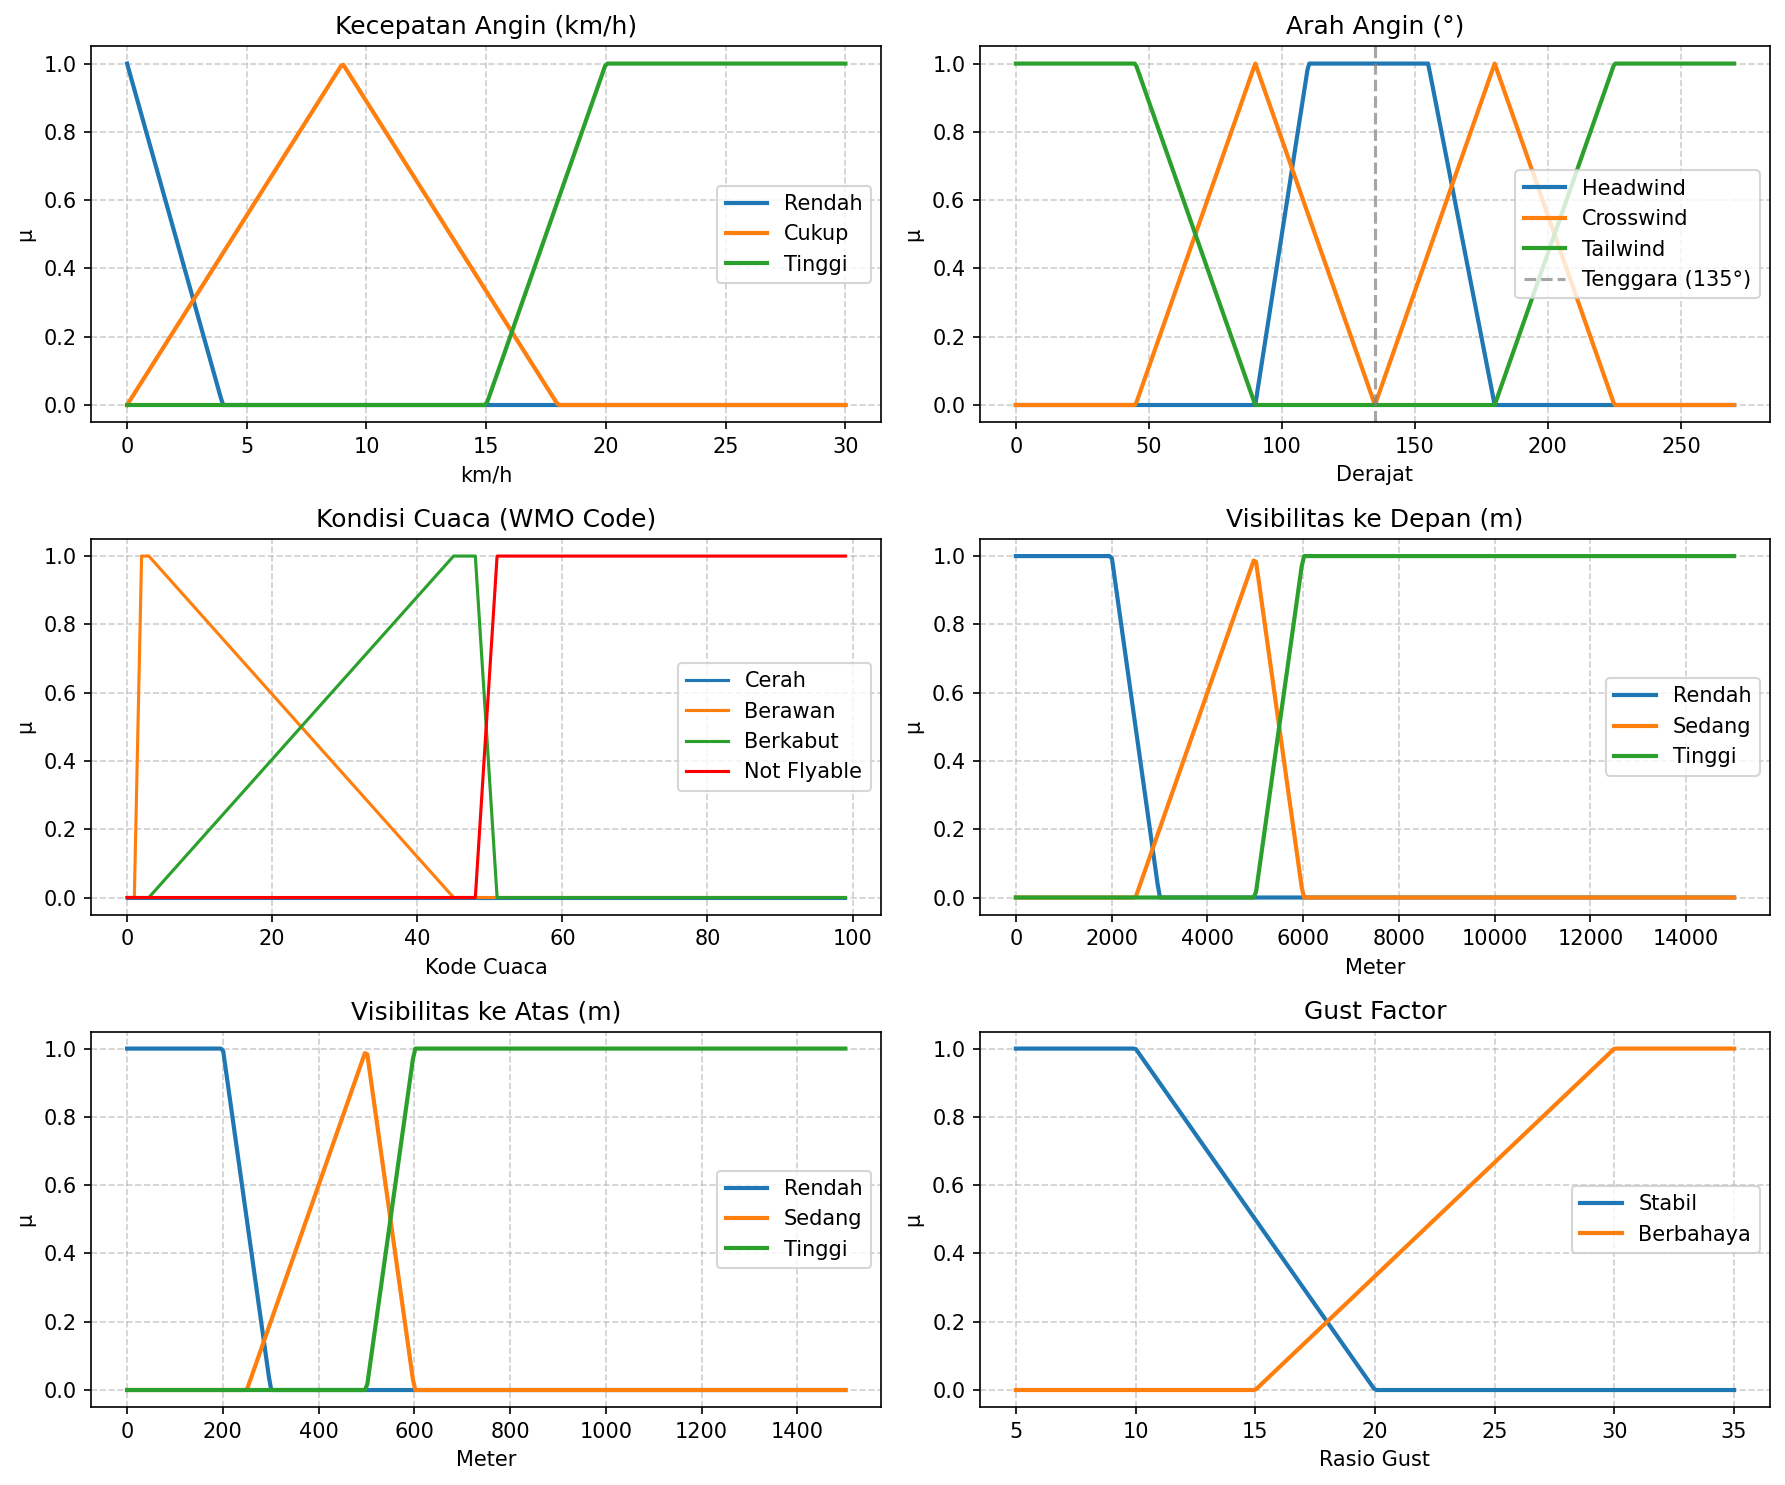

In [ ]:
fig, axs = plt.subplots(3, 2, figsize=(12, 10))

# ===============================
# Kecepatan Angin
# ===============================
x = np.linspace(0, 30, 300)
axs[0,0].plot(x, [mu_kecepatan(v)['rendah'] for v in x], label='Rendah', linewidth=2)
axs[0,0].plot(x, [mu_kecepatan(v)['cukup'] for v in x], label='Cukup', linewidth=2)
axs[0,0].plot(x, [mu_kecepatan(v)['tinggi'] for v in x], label='Tinggi', linewidth=2)
axs[0,0].set_title('Kecepatan Angin (km/h)')
axs[0,0].set_xlabel('km/h')
axs[0,0].set_ylabel('μ')
axs[0,0].grid(True, linestyle='--', alpha=0.6)
axs[0,0].legend()

# ===============================
# Arah Angin
# ===============================
x = np.linspace(0, 270, 400)
axs[0,1].plot(x, [mu_arah(v)['headwind'] for v in x], label='Headwind', linewidth=2)
axs[0,1].plot(x, [mu_arah(v)['crosswind'] for v in x], label='Crosswind', linewidth=2)
axs[0,1].plot(x, [mu_arah(v)['tailwind'] for v in x], label='Tailwind', linewidth=2)
axs[0,1].axvline(135, color='gray', linestyle='--', alpha=0.7, label='Tenggara (135°)')
axs[0,1].set_title('Arah Angin (°)')
axs[0,1].set_xlabel('Derajat')
axs[0,1].set_ylabel('μ')
axs[0,1].grid(True, linestyle='--', alpha=0.6)
axs[0,1].legend()

# ===============================
# Kondisi Cuaca
# ===============================
codes = sorted([
    0, 1, 2, 3, 45, 48, 51, 53, 55,
    61, 63, 65, 80, 81, 82, 95, 96, 99
])

axs[1,0].plot(codes, [mu_weather_code(c)['cerah'] for c in codes], label='Cerah')
axs[1,0].plot(codes, [mu_weather_code(c)['berawan'] for c in codes], label='Berawan')
axs[1,0].plot(codes, [mu_weather_code(c)['berkabut'] for c in codes], label='Berkabut')
axs[1,0].plot(codes, [mu_weather_code(c)['not_flyable'] for c in codes], label='Not Flyable', color='red')
axs[1,0].set_title('Kondisi Cuaca (WMO Code)')
axs[1,0].set_xlabel('Kode Cuaca')
axs[1,0].set_ylabel('μ')
axs[1,0].grid(True, linestyle='--', alpha=0.6)
axs[1,0].legend()

# ===============================
# Visibilitas Depan
# ===============================
x = np.linspace(0, 15000, 300)
axs[1,1].plot(x, [mu_vis_depan(v)['rendah'] for v in x], label='Rendah', linewidth=2)
axs[1,1].plot(x, [mu_vis_depan(v)['sedang'] for v in x], label='Sedang', linewidth=2)
axs[1,1].plot(x, [mu_vis_depan(v)['tinggi'] for v in x], label='Tinggi', linewidth=2)
axs[1,1].set_title('Visibilitas ke Depan (m)')
axs[1,1].set_xlabel('Meter')
axs[1,1].set_ylabel('μ')
axs[1,1].grid(True, linestyle='--', alpha=0.6)
axs[1,1].legend()

# ===============================
# Visibilitas Atas
# ===============================
x = np.linspace(0, 1500, 300)
axs[2,0].plot(x, [mu_vis_atas(v)['rendah'] for v in x], label='Rendah', linewidth=2)
axs[2,0].plot(x, [mu_vis_atas(v)['sedang'] for v in x], label='Sedang', linewidth=2)
axs[2,0].plot(x, [mu_vis_atas(v)['tinggi'] for v in x], label='Tinggi', linewidth=2)
axs[2,0].set_title('Visibilitas ke Atas (m)')
axs[2,0].set_xlabel('Meter')
axs[2,0].set_ylabel('μ')
axs[2,0].grid(True, linestyle='--', alpha=0.6)
axs[2,0].legend()

# ===============================
# Gust Factor
# ===============================
x = np.linspace(5, 35, 300)
axs[2,1].plot(x, [mu_gust(v)['stabil'] for v in x], label='Stabil', linewidth=2)
axs[2,1].plot(x, [mu_gust(v)['berbahaya'] for v in x], label='Berbahaya', linewidth=2)
axs[2,1].set_title('Gust Factor')
axs[2,1].set_xlabel('Rasio Gust')
axs[2,1].set_ylabel('μ')
axs[2,1].grid(True, linestyle='--', alpha=0.6)
axs[2,1].legend()

plt.tight_layout()
plt.show()


In [ ]:
# CONSEQUENTS_3_OUTPUT = {
#     # KC: Bahaya/Tidak Layak
#     'KC': {'target': 35, 'P_prior': 0.95},
#     # KB: Waspada/Bersyarat
#     'KB': {'target': 70, 'P_prior': 0.75},
#     # KA: Ideal/Aman
#     'KA': {'target': 95, 'P_prior': 0.90}
# }
# LABEL_TEXT = {
#     'KC': 'TIDAK LAYAK (Berbahaya)',
#     'KB': 'WASPADA (Layak Bersyarat)',
#     'KA': 'LAYAK (Aman / Ideal)'
# }

In [ ]:
def fuzzifikasi(input_data):
    """
    Mengubah input data cuaca menjadi derajat keanggotaan fuzzy.
    Variabel waktu diabaikan dan tidak dilibatkan dalam proses fuzzifikasi.
    """

    # 1. Kecepatan Angin (km/h)
    fuzz_kecepatan = mu_kecepatan(input_data['kecepatan_angin'])

    # 2. Gust Factor
    fuzz_gust = mu_gust(input_data['gust_factor'])

    # 3. Arah Angin (Derajat)
    fuzz_arah = mu_arah(input_data['arah_angin'])

    # 4. Cuaca (Kode WMO)
    fuzz_cuaca = mu_weather_code(input_data['kode_wmo'])

    # 5. Visibilitas Depan (m)
    fuzz_vis_depan = mu_vis_depan(input_data['vis_depan'])

    # 6. Visibilitas Atas (m)
    fuzz_vis_atas = mu_vis_atas(input_data['vis_atas'])

    return {
        'kecepatan': fuzz_kecepatan,
        'gust': fuzz_gust,
        'arah': fuzz_arah,
        'cuaca': fuzz_cuaca,
        'vis_depan': fuzz_vis_depan,
        'vis_atas': fuzz_vis_atas
    }


In [ ]:
def tnorm_and(*memberships):
    memberships = [float(m) for m in memberships if not np.isnan(m)]
    return min(memberships) if memberships else 0.0

def tconorm_or(*args):
    if not args:
        return 0.0
    return max(args)

def inferensi_probabilistik(fuzz_output):
    """
    Inferensi fuzzy–probabilistik TANPA variabel waktu.
    Sistem bersifat time-independent.
    """

    k  = fuzz_output['kecepatan']
    g  = fuzz_output['gust']
    a  = fuzz_output['arah']
    c  = fuzz_output['cuaca']
    vd = fuzz_output['vis_depan']
    va = fuzz_output['vis_atas']


    # ======================
    # GATE GUSTY (HARUS DI AWAL)
    # ======================
    if k['rendah'] > 0:
        g_effective = g['stabil']
    else:
        g_effective = g['berbahaya']

    # ======================
    # RULE BASE (FINAL)
    # ======================
    rules = [
        (tconorm_or(a['tailwind'], c['not_flyable']), 0.90, 'Dangerous'),

        (tnorm_and(k['tinggi']), 0.75, 'Dangerous'),

        (tnorm_and(tconorm_or(vd['rendah'], va['rendah'])), 0.50, 'Dangerous'),

        (tnorm_and(g_effective, a['crosswind'], k['rendah']), 0.75, 'Caution'),
        (tnorm_and(g_effective, a['crosswind'], k['cukup']), 0.65, 'Caution'),

        (tnorm_and(
            a['headwind'],
            tconorm_or(k['rendah'], k['cukup']),
            tconorm_or(va['sedang'], va['tinggi']),
            tconorm_or(vd['sedang'], vd['tinggi'])
        ), 0.90, 'Safe'),

        (tnorm_and(g_effective, a['headwind'], tconorm_or(k['rendah'], k['cukup'])), 0.50, 'Safe'),

    ]

    # ======================
    # AGREGASI (MAX / T-CONORM)
    # ======================
    omega = {'Safe': 0.0, 'Caution': 0.0, 'Dangerous': 0.0}
    any_fired = False

    for alpha, P, category in rules:
        omega_i = alpha * P
        if omega_i > 0:
            any_fired = True
        omega[category] = max(omega[category], omega_i)


    if not any_fired:
        omega['Caution'] = max(omega['Caution'], 0.90)

    return omega

In [ ]:
def defuzzifikasi_probabilistik(omega):

    # Sentroid untuk tiap kategori fuzzy (skala 0–100)
    sentroids = {
        'Dangerous': 30,   # Tidak Layak / Bahaya
        'Caution': 70,   # Waspada / Bersyarat
        'Safe': 90    # Layak / Ideal
    }

    numerator = 0.0
    denominator = 0.0

    for category, w_val in omega.items():
        if category in sentroids:
            numerator += w_val * sentroids[category]
            denominator += w_val

    # Jika tidak ada aktivasi sama sekali
    if denominator == 0:
        return sentroids['Caution']

    score = numerator / denominator

    # Amankan nilai
    return float(np.clip(score, 0, 100))


In [ ]:
def fuzzy_probabilistic_system(input_data):
    print("TAHAP FUZZIFIKASI")
    fuzz_output = fuzzifikasi(input_data)
    for var, vals in fuzz_output.items():
        print(f"   - {var.capitalize()}: {vals}")

    print("TAHAP INFERENSI PROBABILISTIK")

    omega = inferensi_probabilistik(fuzz_output)
    print(f"   - Derajat Dukungan Probabilistik (Omega): {omega}")

    print("TAHAP DEFUZZIFIKASI PROBABILISTIK")

    pkc = defuzzifikasi_probabilistik(omega)
    print(f"   - Hasil Defuzzifikasi (Skala 0-100): {pkc:.2f}")

    if pkc >= 85:
        kesimpulan = "Safe"
    elif pkc >= 60:
        kesimpulan = "Caution"
    else:
        kesimpulan = "Dangerous"

    return pkc, kesimpulan


In [ ]:
import pandas as pd

def run_fuzzy_from_excel(path_input, path_output):
    # Baca dataset
    df = pd.read_excel(path_input)
    print("File berhasil dibaca:", path_input)

    # ================================
    # 1. Konversi kolom Waktu → jam
    # ================================
    waktu_dt = pd.to_datetime(df["Waktu"])
    df["jam"] = waktu_dt.dt.hour + waktu_dt.dt.minute/60.0

    # Siapkan kolom output
    df["pkc_score"] = 0.0
    df["output"] = ""

    # Loop setiap baris
    for i, row in df.iterrows():

        # ==========================================
        # 2. SESUAIKAN DENGAN fuzzifikasi() MILIKMU
        # ==========================================
        input_data = {
            "jam": row["jam"],
            "kecepatan_angin": row["Kecepatan_Angin_(km/h)"],
            "gust_factor": row["Gust_Factor_(%)"],
            "arah_angin": row["Arah_Angin_(°)"],
            "kode_wmo": row["Cuaca"],
            "vis_depan": row["Visibilitas_Depan_(m)"],
            "vis_atas": row["Visibilitas_Atas_(m)"]
        }

        # Jalankan sistem fuzzy probabilistik
        pkc, hasil = fuzzy_probabilistic_system(input_data)

        # Simpan ke dataframe
        df.at[i, "pkc_score"] = pkc
        df.at[i, "output"] = hasil

    # Simpan hasil
    df.to_excel(path_output, index=False)
    print("Hasil berhasil disimpan ke:", path_output)

    return df


In [ ]:
import pandas as pd

df = pd.read_excel("/content/drive/MyDrive/Tugas Akhir/DATA/Bahan.xlsx")
print(df.columns)


Index(['Waktu', 'Kecepatan_Angin_(km/h)', 'Gust_Factor_(%)', 'Arah_Angin_(°)',
       'Cuaca', 'Visibilitas_Depan_(m)', 'Visibilitas_Atas_(m)'],
      dtype='object')


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df_hasil = run_fuzzy_from_excel(
    "/content/drive/MyDrive/Tugas Akhir/DATA/Bahan.xlsx",
    "/content/drive/MyDrive/Tugas Akhir/DATA/hasil_fuzzy.xlsx"
)


Output streaming akan dipotong hingga 5000 baris terakhir.
   - Vis_atas: {'rendah': 0.0, 'sedang': 0.8647403564453126, 'tinggi': 0.0}
TAHAP INFERENSI PROBABILISTIK
   - Derajat Dukungan Probabilistik (Omega): {'Safe': 0.0, 'Caution': 0.0, 'Dangerous': 0.9}
TAHAP DEFUZZIFIKASI PROBABILISTIK
   - Hasil Defuzzifikasi (Skala 0-100): 30.00
TAHAP FUZZIFIKASI
   - Kecepatan: {'rendah': 0.0, 'cukup': 0.7599999639723036, 'tinggi': 0.0}
   - Gust: {'stabil': 0.0, 'berbahaya': 1.0}
   - Arah: {'headwind': 0.0, 'crosswind': 0.0, 'tailwind': 1.0}
   - Cuaca: {'cerah': 0.0, 'berawan': 0.0, 'berkabut': 0.0, 'not_flyable': 1.0}
   - Vis_depan: {'rendah': 0.0, 'sedang': 0.0, 'tinggi': 1.0}
   - Vis_atas: {'rendah': 0.0, 'sedang': 0.6578731689453124, 'tinggi': 0.0}
TAHAP INFERENSI PROBABILISTIK
   - Derajat Dukungan Probabilistik (Omega): {'Safe': 0.0, 'Caution': 0.0, 'Dangerous': 0.9}
TAHAP DEFUZZIFIKASI PROBABILISTIK
   - Hasil Defuzzifikasi (Skala 0-100): 30.00
TAHAP FUZZIFIKASI
   - Kecepatan: {'re

In [ ]:
def evaluasi_sistem(real_excel, fuzzy_excel):
    df_real = pd.read_excel(real_excel)
    df_fuzzy = pd.read_excel(fuzzy_excel)

    df = pd.merge(
        df_real,
        df_fuzzy[['Waktu', 'output']],
        on='Waktu',
        how='inner'
    )

    # Normalisasi label
    df["output_real"] = df["output_x"].str.strip().str.lower()
    df["output_pred"] = df["output_y"].str.strip().str.lower()

    # Akurasi
    accuracy = (df["output_real"] == df["output_pred"]).mean() * 100

    # Ordinal
    kategori_order = ["safe", "caution", "dangerous"]

    df["real_num"] = pd.Categorical(
        df["output_real"], categories=kategori_order, ordered=True
    ).codes + 1

    df["pred_num"] = pd.Categorical(
        df["output_pred"], categories=kategori_order, ordered=True
    ).codes + 1

    # Filter valid
    df_valid = df[df["real_num"] > 0].copy()

    # MAPE
    df_valid.loc[:, "APE"] = (
        abs(df_valid["real_num"] - df_valid["pred_num"]) /
        df_valid["real_num"]
    ) * 100

    mape = df_valid["APE"].mean()

    print("=== Evaluation Results ===")
    print(f"Accuracy : {accuracy:.2f}%")
    print(f"MAPE     : {mape:.2f}%")

    return df_valid, mape, accuracy


# Contoh pemanggilan
df_eval, nilai_mape, nilai_akurasi = evaluasi_sistem(
    "/content/drive/MyDrive/Tugas Akhir/DATA/Eval.xlsx",
    "/content/drive/MyDrive/Tugas Akhir/DATA/hasil_fuzzy.xlsx"
)

df_eval.to_excel("/content/drive/MyDrive/Tugas Akhir/DATA/hasil_eval_mape.xlsx", index=False)



=== Evaluation Results ===
Accuracy : 81.44%
MAPE     : 9.30%


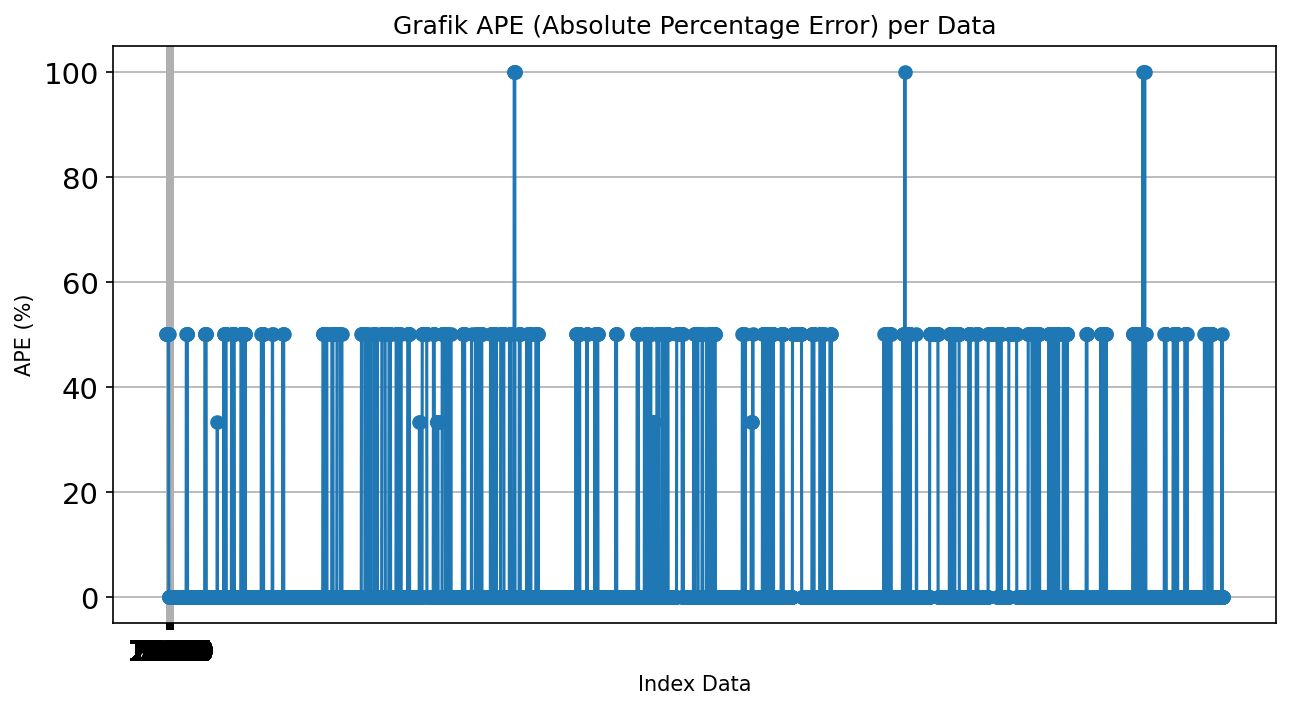

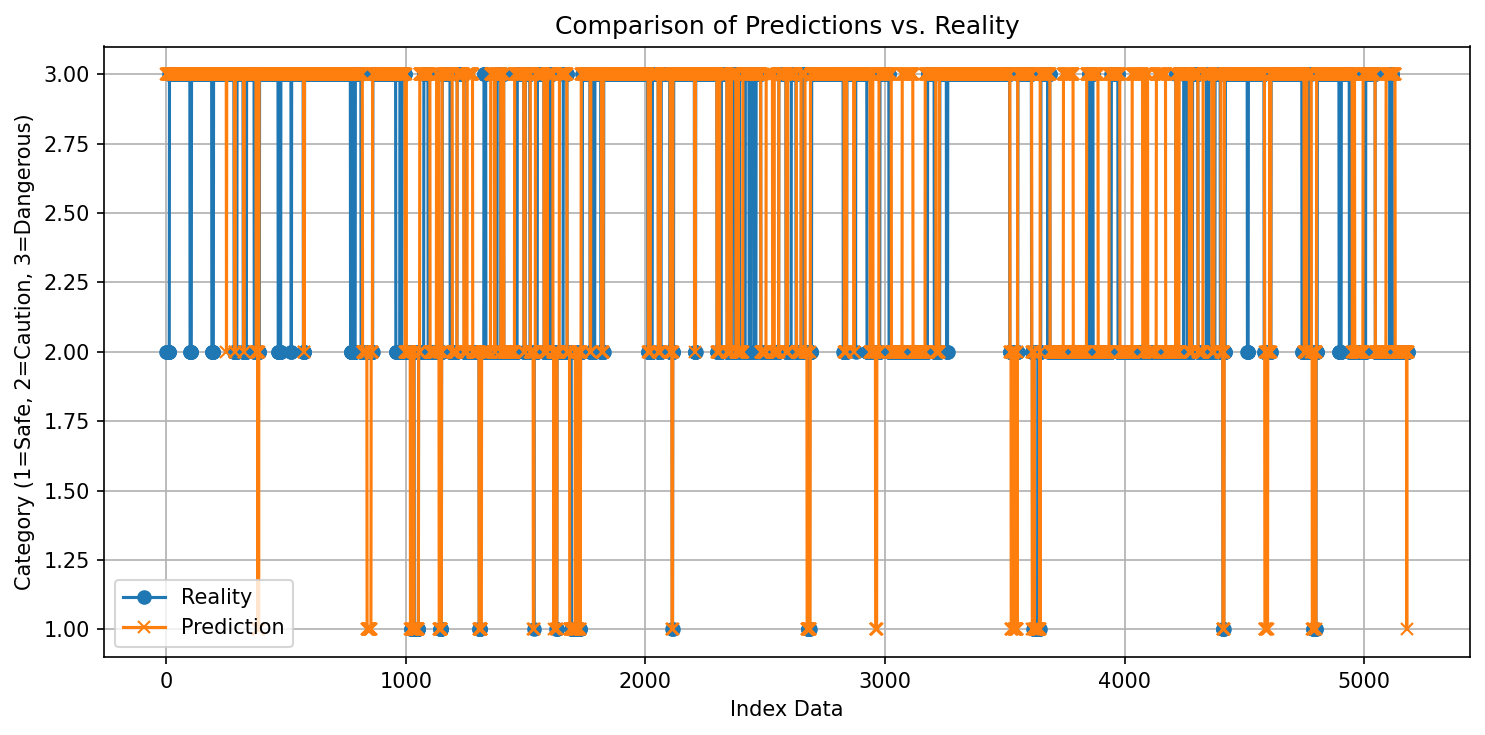

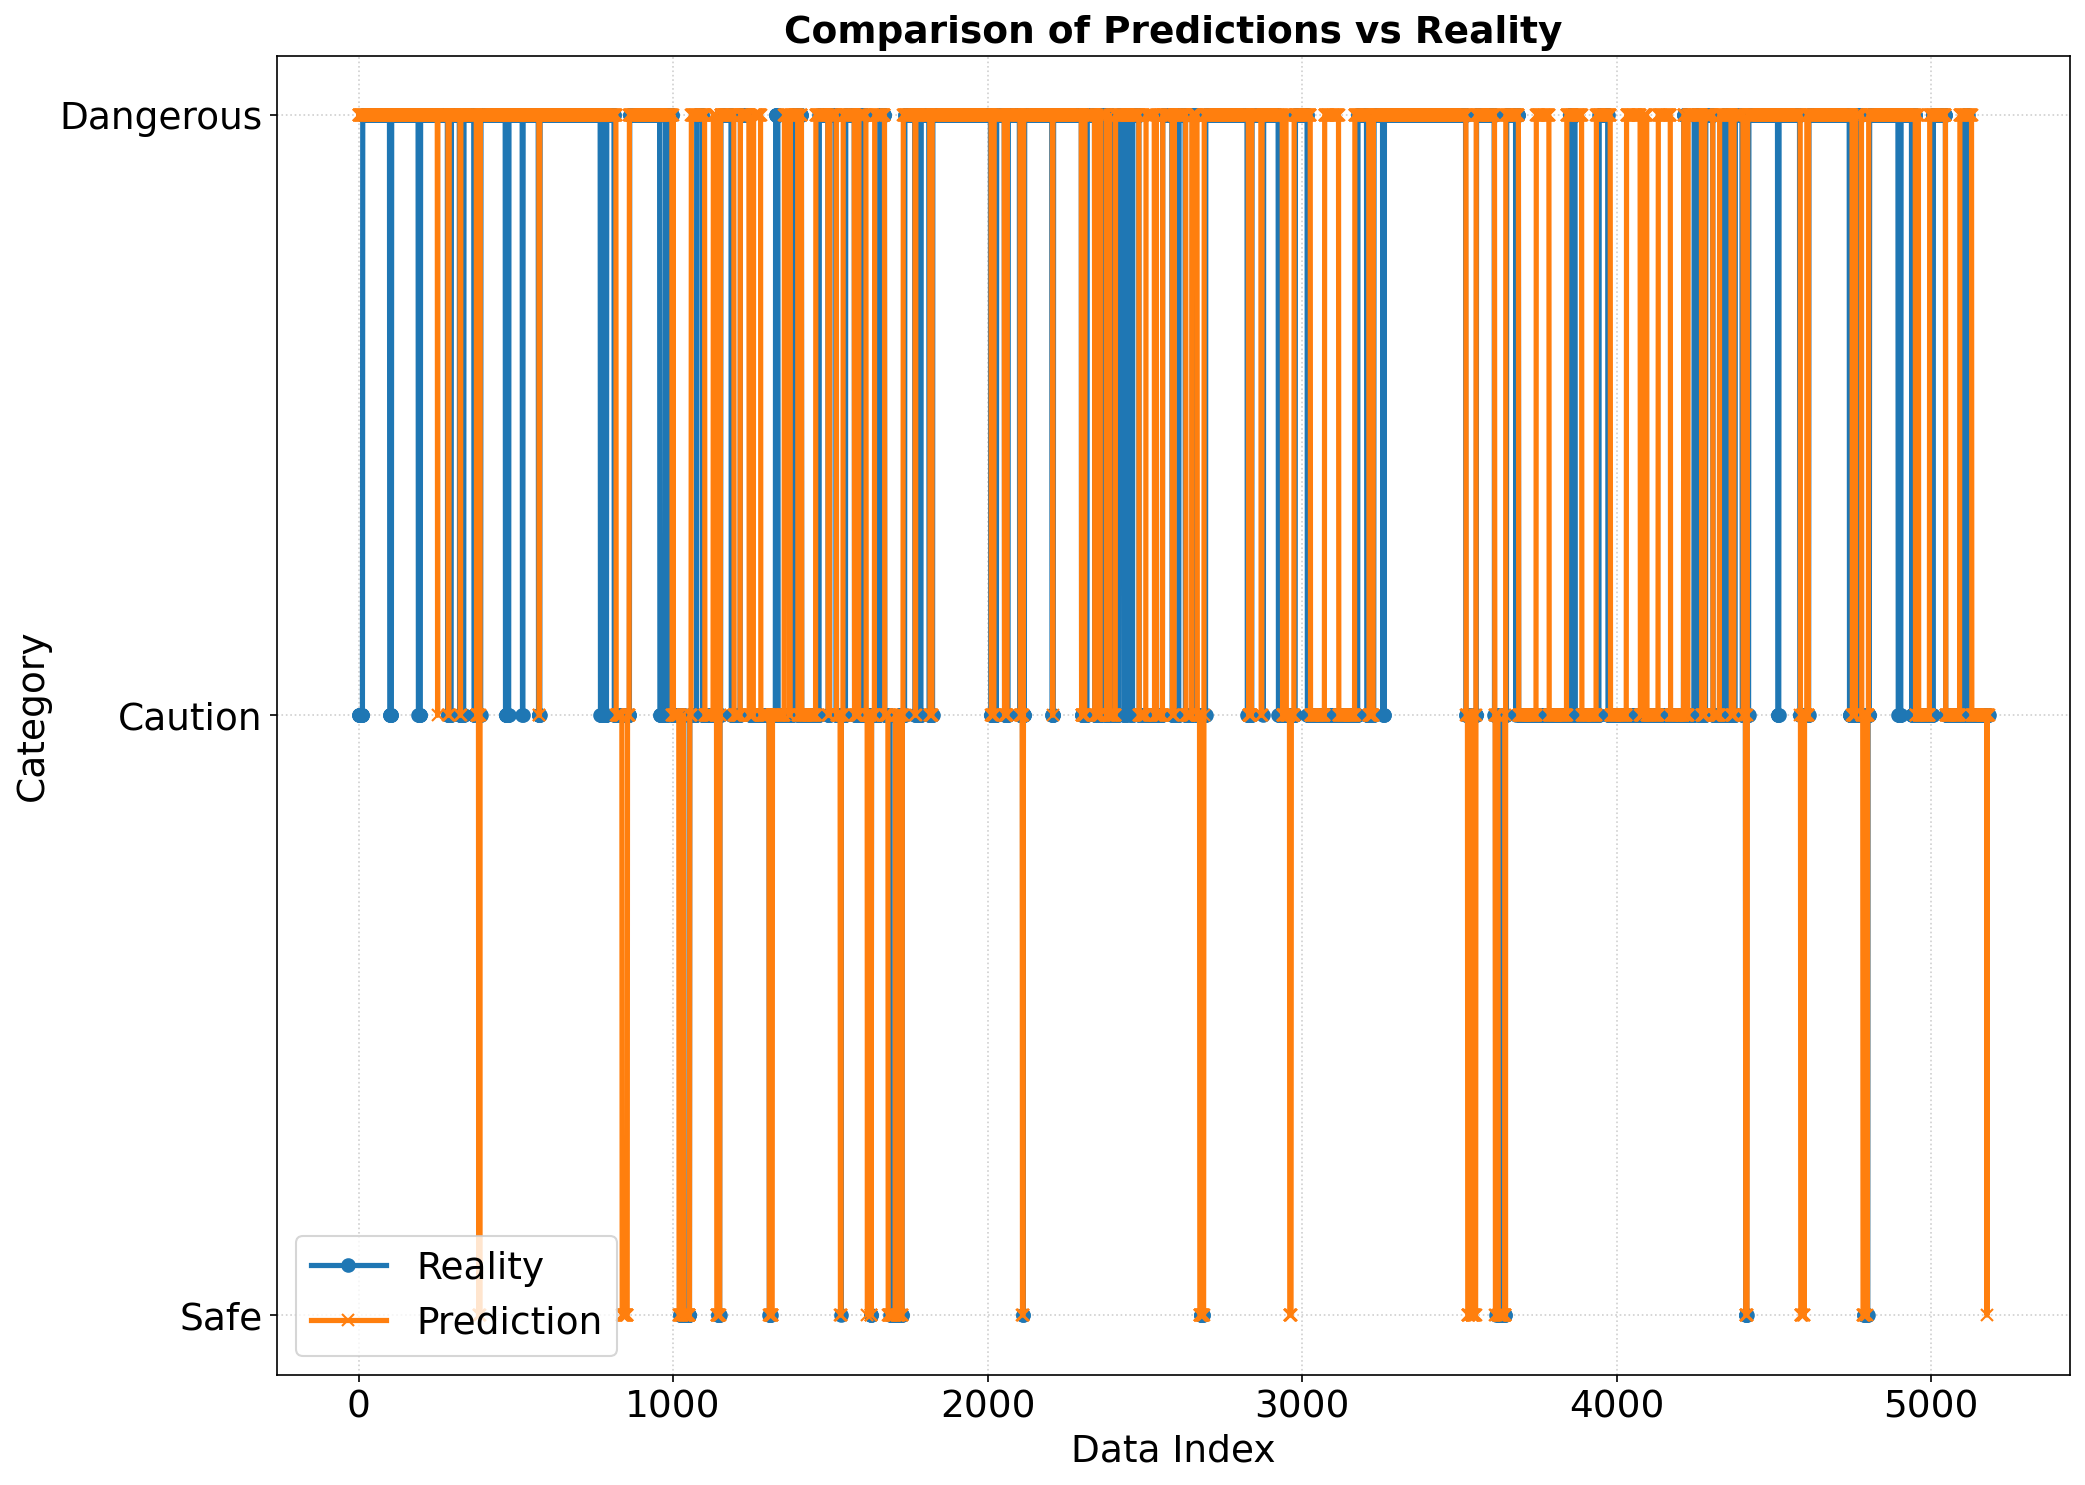

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_excel("/content/drive/MyDrive/Tugas Akhir/DATA/hasil_eval_mape.xlsx")

# Grafik APE
plt.figure(figsize=(10,5))
plt.plot(df["APE"], marker='o')
plt.title("Grafik APE (Absolute Percentage Error) per Data")
plt.xlabel("Index Data")
plt.ylabel("APE (%)")
plt.grid(True)
plt.xticks(x, fontsize=14)
plt.yticks(fontsize=14)
plt.show()

# Grafik Prediksi vs Realita
plt.figure(figsize=(10,5))
plt.plot(df["real_num"], label="Reality", marker='o')
plt.plot(df["pred_num"], label="Prediction", marker='x')
plt.title("Comparison of Predictions vs. Reality")
plt.xlabel("Index Data")
plt.ylabel("Category (1=Safe, 2=Caution, 3=Dangerous)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

import matplotlib.pyplot as plt

plt.rcParams['figure.dpi'] = 150  # biar tajam

plt.figure(figsize=(14,10))  # lebih besar

plt.plot(df["real_num"],
         label="Reality",
         marker='o',
         linewidth=2.5,
         markersize=6)

plt.plot(df["pred_num"],
         label="Prediction",
         marker='x',
         linewidth=2.5,
         markersize=6)

# === JUDUL & LABEL DIPERBESAR ===
plt.title("Comparison of Predictions vs Reality", fontsize=18, fontweight='bold')
plt.xlabel("Data Index", fontsize=18)
plt.ylabel("Category", fontsize=18)

# === UBAH Y-AXIS JADI LABEL (PENTING BANGET) ===
plt.yticks([1, 2, 3],
           ["Safe", "Caution", "Dangerous"],
           fontsize=18)

plt.xticks(fontsize=18)

plt.grid(True, linestyle=':', alpha=0.6)

# Legend lebih jelas
plt.legend(fontsize=18)

plt.tight_layout()

plt.savefig("grafik_prediksi.png",
            dpi=300,              # kualitas tinggi (300 = standar publikasi)
            bbox_inches='tight') # biar tidak kepotong

plt.show()

